In [1]:
import locale
def getpreferredencoding(do_setlocale = True):
  return "UTF-8"
locale.getpreferredencoding = getpreferredencoding

In [2]:
from langchain_community.llms import LlamaCpp
from langchain_core.callbacks import CallbackManager, StreamingStdOutCallbackHandler
from langchain_core.prompts import PromptTemplate
#
n_gpu_layers = -1  # The number of layers to put on the GPU. The rest will be on the CPU. If you don't know how many layers there are, you can use -1 to move all to GPU.
n_batch = 512  # Should be between 1 and n_ctx, consider the amount of VRAM in your GPU.
#
# Callbacks support token-wise streaming
callback_manager = CallbackManager([StreamingStdOutCallbackHandler()])
#
# Make sure the model path is correct for your system!
model = LlamaCpp(
    model_path="zephyr-7b-beta.Q4_K_M.gguf",
    n_gpu_layers=n_gpu_layers,
    n_batch=n_batch,
    temperature=0.75,
    max_tokens=1000,
    top_p=1,
    n_ctx=35000,
    callback_manager=callback_manager,
    verbose=True,  # Verbose is required to pass to the callback manager
)

llama_model_loader: loaded meta data with 21 key-value pairs and 291 tensors from zephyr-7b-beta.Q4_K_M.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = llama
llama_model_loader: - kv   1:                               general.name str              = huggingfaceh4_zephyr-7b-beta
llama_model_loader: - kv   2:                       llama.context_length u32              = 32768
llama_model_loader: - kv   3:                     llama.embedding_length u32              = 4096
llama_model_loader: - kv   4:                          llama.block_count u32              = 32
llama_model_loader: - kv   5:                  llama.feed_forward_length u32              = 14336
llama_model_loader: - kv   6:                 llama.rope.dimension_count u32              = 128
llama_model_loader: - kv   7:                 llama.attention.h

In [3]:
from langchain.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
#
EMBEDDING_MODEL_NAME = "thenlper/gte-small"

embd = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL_NAME,
    multi_process=True,
    model_kwargs={"device": "cuda"},
    encode_kwargs={"normalize_embeddings": True},  # set True for cosine similarity
)

C:\Users\hasee\AppData\Local\Temp\ipykernel_16396\403431965.py:7: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embd = HuggingFaceEmbeddings(
c:\Users\hasee\miniconda3\envs\finetuning_course\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# import matplotlib.pyplot as plt
# import tiktoken
# from bs4 import BeautifulSoup as Soup
# from langchain_community.document_loaders.recursive_url_loader import RecursiveUrlLoader
# def num_tokens_from_string(string: str, encoding_name: str) -> int:
#     encoding = tiktoken.get_encoding(encoding_name)
#     num_tokens = len(encoding.encode(string))
#     return num_tokens

# url = "https://python.langchain.com/docs/expression_language/"
# loader = RecursiveUrlLoader(url, max_depth=20, extractor = lambda x: Soup(x, "html.parser").text)
# docs = loader.load()
# docs_texts = [doc.page_content for doc in docs]

In [5]:
# import matplotlib.pyplot as plt
# import tiktoken
# from bs4 import BeautifulSoup as Soup
# from langchain_community.document_loaders.recursive_url_loader import RecursiveUrlLoader

# ## Helper Fuction to count the number of Tokensin each text
# def num_tokens_from_string(string: str, encoding_name: str) -> int:
#     """Returns the number of tokens in a text string."""
#     encoding = tiktoken.get_encoding(encoding_name)
#     num_tokens = len(encoding.encode(string))
#     return num_tokens
# #
# # LCEL docs
# url = "https://python.langchain.com/docs/expression_language/"
# loader = RecursiveUrlLoader(
#     url=url, max_depth=20, extractor=lambda x: Soup(x, "html.parser").text
# )
# docs = loader.load()

# # LCEL w/ PydanticOutputParser (outside the primary LCEL docs)
# url = "https://python.langchain.com/docs/how_to/output_parser_structured/"
# loader = RecursiveUrlLoader(
#     url=url, max_depth=1, extractor=lambda x: Soup(x, "html.parser").text
# )
# docs_pydantic = loader.load()

# # LCEL w/ Self Query (outside the primary LCEL docs)
# url = "https://python.langchain.com/docs/how_to/self_query/"
# loader = RecursiveUrlLoader(
#     url=url, max_depth=1, extractor=lambda x: Soup(x, "html.parser").text
# )
# docs_sq = loader.load()

# # Doc texts
# docs.extend([*docs_pydantic, *docs_sq])
# docs_texts = [d.page_content for d in docs]


In [26]:
import matplotlib.pyplot as plt
import tiktoken
from langchain_community.document_loaders import PyPDFLoader
   # Assuming a PDFLoader exists

## Helper Fuction to count the number of Tokensin each text
def num_tokens_from_string(string: str, encoding_name: str) -> int:
    """Returns the number of tokens in a text string."""
    encoding = tiktoken.get_encoding(encoding_name)
    num_tokens = len(encoding.encode(string))
    return num_tokens

# Load Employee Handbook PDF
pdf_path = "Employee Handbook.pdf"
loader = PyPDFLoader(file_path=pdf_path)
docs = loader.load()

# Doc texts
docs_texts = [d.page_content for d in docs]

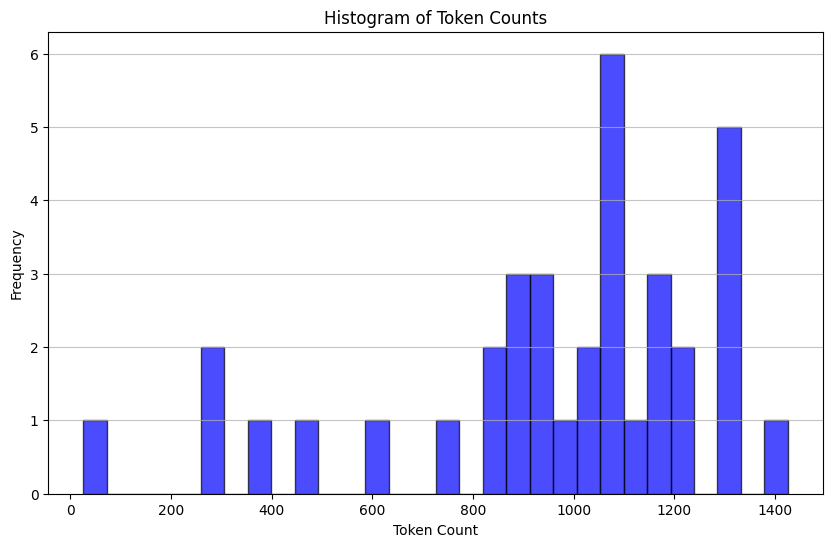

In [27]:
counts = [num_tokens_from_string(d, "cl100k_base") for d in docs_texts]

# Plotting the histogram of token counts
plt.figure(figsize=(10, 6))
plt.hist(counts, bins=30, color="blue", edgecolor="black", alpha=0.7)
plt.title("Histogram of Token Counts")
plt.xlabel("Token Count")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)

# Display the histogram
plt.show()

In [28]:
# Doc texts concat
d_sorted = sorted(docs, key=lambda x: x.metadata["source"])
d_reversed = list(reversed(d_sorted))
concatenated_content = "\n\n\n --- \n\n\n".join(
    [doc.page_content for doc in d_reversed]
)
print(
    "Num tokens in all context: %s"
    % num_tokens_from_string(concatenated_content, "cl100k_base")
)


Num tokens in all context: 34575


In [29]:
# Doc texts split
from langchain_text_splitters import RecursiveCharacterTextSplitter

chunk_size_tok = 1000
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=chunk_size_tok, chunk_overlap=0
)
texts_split = text_splitter.split_text(concatenated_content)
#
print(f"Number of text splits generated: {len(texts_split)}")

Number of text splits generated: 100


In [30]:
global_embeddings = [embd.embed_query(txt) for txt in texts_split]
print(len(global_embeddings[0]))

384


[6.2129188 2.1816738]


c:\Users\hasee\miniconda3\envs\finetuning_course\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


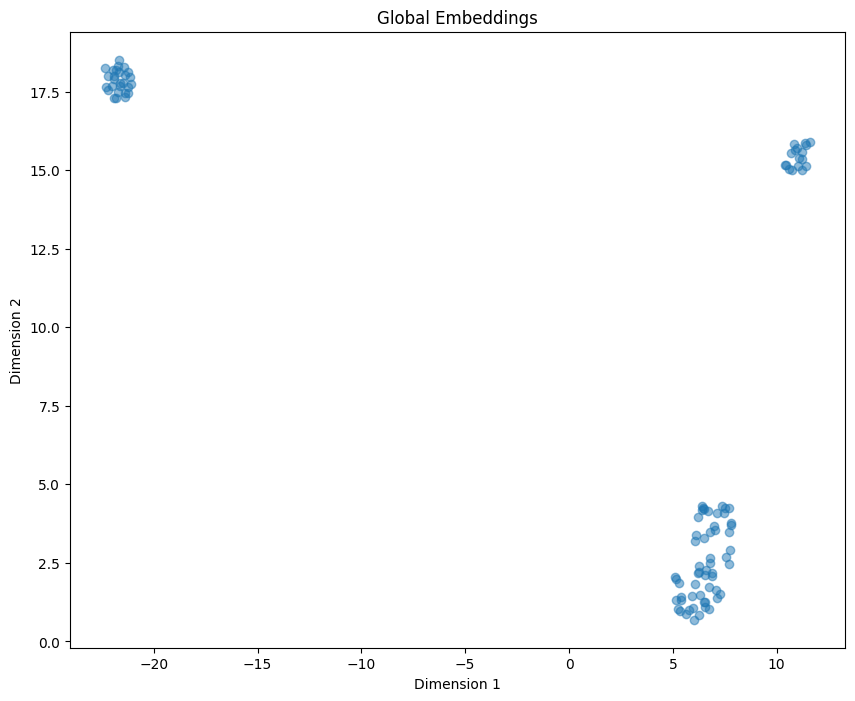

In [31]:
import matplotlib.pyplot as plt
from typing import Optional
import numpy as np
import umap

def reduce_cluster_embeddings(
    embeddings: np.ndarray,
    dim: int,
    n_neighbors: Optional[int] = None,
    metric: str = "cosine",
) -> np.ndarray:
    if n_neighbors is None:
        n_neighbors = int((len(embeddings) - 1) ** 0.5)
    return umap.UMAP(
        n_neighbors=n_neighbors, n_components=dim, metric=metric
    ).fit_transform(embeddings)

dim = 2
global_embeddings_reduced = reduce_cluster_embeddings(global_embeddings, dim)
print(global_embeddings_reduced[0])
#
plt.figure(figsize=(10, 8))
plt.scatter(global_embeddings_reduced[:, 0], global_embeddings_reduced[:, 1], alpha=0.5)
plt.title("Global Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

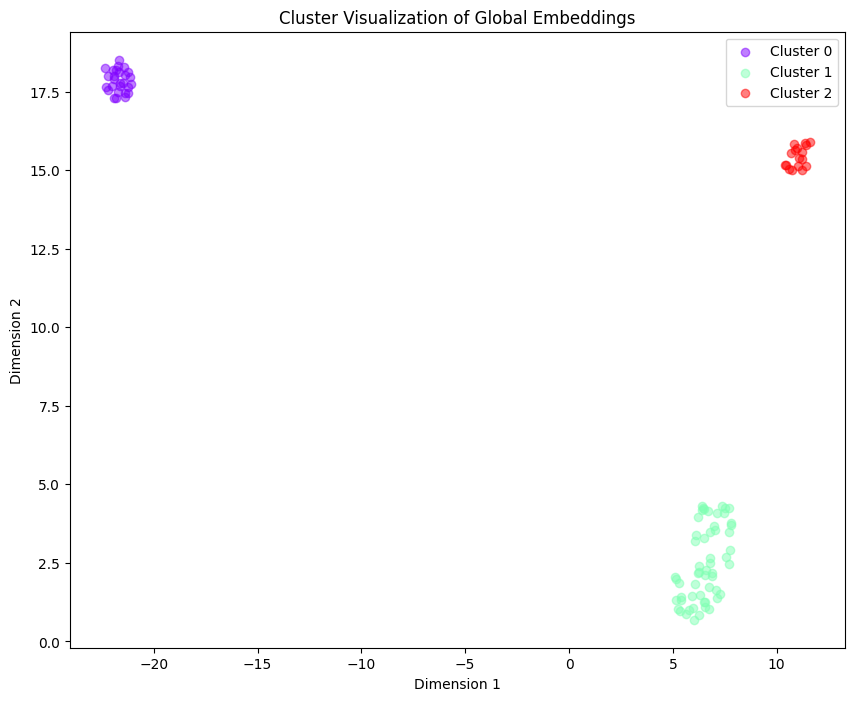

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.mixture import GaussianMixture

def get_optimal_clusters(embeddings: np.ndarray, max_clusters: int = 50, random_state: int = 1234):
    max_clusters = min(max_clusters, len(embeddings))
    bics = [GaussianMixture(n_components=n, random_state=random_state).fit(embeddings).bic(embeddings)
            for n in range(1, max_clusters)]
    return np.argmin(bics) + 1

def gmm_clustering(embeddings: np.ndarray, threshold: float, random_state: int = 0):
    n_clusters = get_optimal_clusters(embeddings)
    gm = GaussianMixture(n_components=n_clusters, random_state=random_state).fit(embeddings)
    probs = gm.predict_proba(embeddings)
    labels = [np.where(prob > threshold)[0] for prob in probs]
    return labels, n_clusters
#
labels, _ = gmm_clustering(global_embeddings_reduced, threshold=0.5)

plot_labels = np.array([label[0] if len(label) > 0 else -1 for label in labels])
plt.figure(figsize=(10, 8))

unique_labels = np.unique(plot_labels)
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    mask = plot_labels == label
    plt.scatter(global_embeddings_reduced[mask, 0], global_embeddings_reduced[mask, 1], color=color, label=f'Cluster {label}', alpha=0.5)

plt.title("Cluster Visualization of Global Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.show()

In [33]:
import pandas as pd

simple_labels = [label[0] if len(label) > 0 else -1 for label in labels]

df = pd.DataFrame({
    'Text': texts_split,
    'Embedding': list(global_embeddings_reduced),
    'Cluster': simple_labels
})
print(df.head(3))

                                                Text               Embedding  \
0  Was  Police  Dept.  Notified  ___yes  ____no  ...  [6.2129188, 2.1816738]   
1  At  the  time  of  your  termination,  you  wi...   [7.086524, 1.6458433]   
2  If  any  hotel  materials,  supplies,  or  cle...   [7.5461497, 2.681627]   

   Cluster  
0        1  
1        1  
2        1  


In [34]:
def format_cluster_texts(df):
    clustered_texts = {}
    for cluster in df['Cluster'].unique():
        cluster_texts = df[df['Cluster'] == cluster]['Text'].tolist()
        clustered_texts[cluster] = " --- ".join(cluster_texts)
    return clustered_texts
#
clustered_texts = format_cluster_texts(df)
#
clustered_texts

{1: 'Was  Police  Dept.  Notified  ___yes  ____no  Fire  Dept.  ____yes  ____no  Incident  Report  Please  provide  a  brief  description  of  the  type  of  damage:  _____  Injury  to  Person  __________________________________________________________________________  _____  Damage  to  Property  ______________________________________________________________________  \n_____\n \nOther\n \n(describe)__________________________________________________________________________\n \n Name  of  Party  ___________________________________________________  \nPhone___________________________\n \n Address  (include  complete  address,  with  street  address,  city,  state  and  zip)  \n________________________________________________________________________________________\n Driver\'s  License  No.  \n________________________________________________________________________________\n \n Briefly  Describe  What  Happened:  \n_____________________________________________________________________\n \n_

In [35]:
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import umap
from langchain.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from sklearn.mixture import GaussianMixture

RANDOM_SEED = 224  # Fixed seed for reproducibility

### --- Code from citations referenced above (added comments and docstrings) --- ###


def global_cluster_embeddings(
    embeddings: np.ndarray,
    dim: int,
    n_neighbors: Optional[int] = None,
    metric: str = "cosine",
) -> np.ndarray:
    """
    Perform global dimensionality reduction on the embeddings using UMAP.

    Parameters:
    - embeddings: The input embeddings as a numpy array.
    - dim: The target dimensionality for the reduced space.
    - n_neighbors: Optional; the number of neighbors to consider for each point.
                   If not provided, it defaults to the square root of the number of embeddings.
    - metric: The distance metric to use for UMAP.

    Returns:
    - A numpy array of the embeddings reduced to the specified dimensionality.
    """
    if n_neighbors is None:
        n_neighbors = int((len(embeddings) - 1) ** 0.5)
    return umap.UMAP(
        n_neighbors=n_neighbors, n_components=dim, metric=metric
    ).fit_transform(embeddings)


def local_cluster_embeddings(
    embeddings: np.ndarray, dim: int, num_neighbors: int = 10, metric: str = "cosine"
) -> np.ndarray:
    """
    Perform local dimensionality reduction on the embeddings using UMAP, typically after global clustering.

    Parameters:
    - embeddings: The input embeddings as a numpy array.
    - dim: The target dimensionality for the reduced space.
    - num_neighbors: The number of neighbors to consider for each point.
    - metric: The distance metric to use for UMAP.

    Returns:
    - A numpy array of the embeddings reduced to the specified dimensionality.
    """
    return umap.UMAP(
        n_neighbors=num_neighbors, n_components=dim, metric=metric
    ).fit_transform(embeddings)


def get_optimal_clusters(
    embeddings: np.ndarray, max_clusters: int = 50, random_state: int = RANDOM_SEED
) -> int:
    """
    Determine the optimal number of clusters using the Bayesian Information Criterion (BIC) with a Gaussian Mixture Model.

    Parameters:
    - embeddings: The input embeddings as a numpy array.
    - max_clusters: The maximum number of clusters to consider.
    - random_state: Seed for reproducibility.

    Returns:
    - An integer representing the optimal number of clusters found.
    """
    max_clusters = min(max_clusters, len(embeddings))
    n_clusters = np.arange(1, max_clusters)
    bics = []
    for n in n_clusters:
        gm = GaussianMixture(n_components=n, random_state=random_state)
        gm.fit(embeddings)
        bics.append(gm.bic(embeddings))
    return n_clusters[np.argmin(bics)]


def GMM_cluster(embeddings: np.ndarray, threshold: float, random_state: int = 0):
    """
    Cluster embeddings using a Gaussian Mixture Model (GMM) based on a probability threshold.

    Parameters:
    - embeddings: The input embeddings as a numpy array.
    - threshold: The probability threshold for assigning an embedding to a cluster.
    - random_state: Seed for reproducibility.

    Returns:
    - A tuple containing the cluster labels and the number of clusters determined.
    """
    n_clusters = get_optimal_clusters(embeddings)
    gm = GaussianMixture(n_components=n_clusters, random_state=random_state)
    gm.fit(embeddings)
    probs = gm.predict_proba(embeddings)
    labels = [np.where(prob > threshold)[0] for prob in probs]
    return labels, n_clusters


def perform_clustering(
    embeddings: np.ndarray,
    dim: int,
    threshold: float,
) -> List[np.ndarray]:
    """
    Perform clustering on the embeddings by first reducing their dimensionality globally, then clustering
    using a Gaussian Mixture Model, and finally performing local clustering within each global cluster.

    Parameters:
    - embeddings: The input embeddings as a numpy array.
    - dim: The target dimensionality for UMAP reduction.
    - threshold: The probability threshold for assigning an embedding to a cluster in GMM.

    Returns:
    - A list of numpy arrays, where each array contains the cluster IDs for each embedding.
    """
    if len(embeddings) <= dim + 1:
        # Avoid clustering when there's insufficient data
        return [np.array([0]) for _ in range(len(embeddings))]

    # Global dimensionality reduction
    reduced_embeddings_global = global_cluster_embeddings(embeddings, dim)
    # Global clustering
    global_clusters, n_global_clusters = GMM_cluster(
        reduced_embeddings_global, threshold
    )

    all_local_clusters = [np.array([]) for _ in range(len(embeddings))]
    total_clusters = 0

    # Iterate through each global cluster to perform local clustering
    for i in range(n_global_clusters):
        # Extract embeddings belonging to the current global cluster
        global_cluster_embeddings_ = embeddings[
            np.array([i in gc for gc in global_clusters])
        ]

        if len(global_cluster_embeddings_) == 0:
            continue
        if len(global_cluster_embeddings_) <= dim + 1:
            # Handle small clusters with direct assignment
            local_clusters = [np.array([0]) for _ in global_cluster_embeddings_]
            n_local_clusters = 1
        else:
            # Local dimensionality reduction and clustering
            reduced_embeddings_local = local_cluster_embeddings(
                global_cluster_embeddings_, dim
            )
            local_clusters, n_local_clusters = GMM_cluster(
                reduced_embeddings_local, threshold
            )

        # Assign local cluster IDs, adjusting for total clusters already processed
        for j in range(n_local_clusters):
            local_cluster_embeddings_ = global_cluster_embeddings_[
                np.array([j in lc for lc in local_clusters])
            ]
            indices = np.where(
                (embeddings == local_cluster_embeddings_[:, None]).all(-1)
            )[1]
            for idx in indices:
                all_local_clusters[idx] = np.append(
                    all_local_clusters[idx], j + total_clusters
                )

        total_clusters += n_local_clusters

    return all_local_clusters


### --- Our code below --- ###


def embed(texts):
    """
    Generate embeddings for a list of text documents.

    This function assumes the existence of an `embd` object with a method `embed_documents`
    that takes a list of texts and returns their embeddings.

    Parameters:
    - texts: List[str], a list of text documents to be embedded.

    Returns:
    - numpy.ndarray: An array of embeddings for the given text documents.
    """
    text_embeddings = embd.embed_documents(texts)
    text_embeddings_np = np.array(text_embeddings)
    return text_embeddings_np


def embed_cluster_texts(texts):
    """
    Embeds a list of texts and clusters them, returning a DataFrame with texts, their embeddings, and cluster labels.

    This function combines embedding generation and clustering into a single step. It assumes the existence
    of a previously defined `perform_clustering` function that performs clustering on the embeddings.

    Parameters:
    - texts: List[str], a list of text documents to be processed.

    Returns:
    - pandas.DataFrame: A DataFrame containing the original texts, their embeddings, and the assigned cluster labels.
    """
    text_embeddings_np = embed(texts)  # Generate embeddings
    cluster_labels = perform_clustering(
        text_embeddings_np, 10, 0.1
    )  # Perform clustering on the embeddings
    df = pd.DataFrame()  # Initialize a DataFrame to store the results
    df["text"] = texts  # Store original texts
    df["embd"] = list(text_embeddings_np)  # Store embeddings as a list in the DataFrame
    df["cluster"] = cluster_labels  # Store cluster labels
    return df


def fmt_txt(df: pd.DataFrame) -> str:
    """
    Formats the text documents in a DataFrame into a single string.

    Parameters:
    - df: DataFrame containing the 'text' column with text documents to format.

    Returns:
    - A single string where all text documents are joined by a specific delimiter.
    """
    unique_txt = df["text"].tolist()
    return "--- --- \n --- --- ".join(unique_txt)


def embed_cluster_summarize_texts(
    texts: List[str], level: int
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Embeds, clusters, and summarizes a list of texts. This function first generates embeddings for the texts,
    clusters them based on similarity, expands the cluster assignments for easier processing, and then summarizes
    the content within each cluster.

    Parameters:
    - texts: A list of text documents to be processed.
    - level: An integer parameter that could define the depth or detail of processing.

    Returns:
    - Tuple containing two DataFrames:
      1. The first DataFrame (`df_clusters`) includes the original texts, their embeddings, and cluster assignments.
      2. The second DataFrame (`df_summary`) contains summaries for each cluster, the specified level of detail,
         and the cluster identifiers.
    """

    # Embed and cluster the texts, resulting in a DataFrame with 'text', 'embd', and 'cluster' columns
    df_clusters = embed_cluster_texts(texts)

    # Prepare to expand the DataFrame for easier manipulation of clusters
    expanded_list = []

    # Expand DataFrame entries to document-cluster pairings for straightforward processing
    for index, row in df_clusters.iterrows():
        for cluster in row["cluster"]:
            expanded_list.append(
                {"text": row["text"], "embd": row["embd"], "cluster": cluster}
            )

    # Create a new DataFrame from the expanded list
    expanded_df = pd.DataFrame(expanded_list)

    # Retrieve unique cluster identifiers for processing
    all_clusters = expanded_df["cluster"].unique()

    print(f"--Generated {len(all_clusters)} clusters--")

    # Summarization
    template = """Here is a sub-set of Google EMployee handbook doc.

    Give a detailed summary of the documentation provided.

    Documentation:
    {context}
    """
    prompt = ChatPromptTemplate.from_template(template)
    chain = prompt | model | StrOutputParser()

    # Format text within each cluster for summarization
    summaries = []
    for i in all_clusters:
        df_cluster = expanded_df[expanded_df["cluster"] == i]
        formatted_txt = fmt_txt(df_cluster)
        summaries.append(chain.invoke({"context": formatted_txt}))

    # Create a DataFrame to store summaries with their corresponding cluster and level
    df_summary = pd.DataFrame(
        {
            "summaries": summaries,
            "level": [level] * len(summaries),
            "cluster": list(all_clusters),
        }
    )

    return df_clusters, df_summary


def recursive_embed_cluster_summarize(
    texts: List[str], level: int = 1, n_levels: int = 3
) -> Dict[int, Tuple[pd.DataFrame, pd.DataFrame]]:
    """
    Recursively embeds, clusters, and summarizes texts up to a specified level or until
    the number of unique clusters becomes 1, storing the results at each level.

    Parameters:
    - texts: List[str], texts to be processed.
    - level: int, current recursion level (starts at 1).
    - n_levels: int, maximum depth of recursion.

    Returns:
    - Dict[int, Tuple[pd.DataFrame, pd.DataFrame]], a dictionary where keys are the recursion
      levels and values are tuples containing the clusters DataFrame and summaries DataFrame at that level.
    """
    results = {}  # Dictionary to store results at each level

    # Perform embedding, clustering, and summarization for the current level
    df_clusters, df_summary = embed_cluster_summarize_texts(texts, level)

    # Store the results of the current level
    results[level] = (df_clusters, df_summary)

    # Determine if further recursion is possible and meaningful
    unique_clusters = df_summary["cluster"].nunique()
    if level < n_levels and unique_clusters > 1:
        # Use summaries as the input texts for the next level of recursion
        new_texts = df_summary["summaries"].tolist()
        next_level_results = recursive_embed_cluster_summarize(
            new_texts, level + 1, n_levels
        )

        # Merge the results from the next level into the current results dictionary
        results.update(next_level_results)

    return results

In [36]:
# leaf_texts = docs_texts
leaf_texts = texts_split
results = recursive_embed_cluster_summarize(leaf_texts, level=1, n_levels=3)

c:\Users\hasee\miniconda3\envs\finetuning_course\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\hasee\miniconda3\envs\finetuning_course\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\hasee\miniconda3\envs\finetuning_course\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\hasee\miniconda3\envs\finetuning_course\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\hasee\miniconda3\envs\finetuning_course\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarni

--Generated 22 clusters--


Llama.generate: 3 prefix-match hit, remaining 6724 prompt tokens to eval


 a
     serious
     offense
 
under any circumstances).
 
I.  Employment  at  Will--- --- 
 --- --- of
 
employment
 
with
 
the
 
Company
 
is
 
at
 
will,
 
and
 
may
 
be
 
terminated
 
by
 
either
 
party
 
for
 
any
 
reason
 
or
 
no
 
reason.
  
The Company does not recognize any common law rights, nor any employment contracts other than as provided in  
 
this
 
policy,
 
and
 
these
 
policies
 
may
 
be modified at any time by the Company without notice to Employees.
 
I.  Protection  of  Trade  Secrets--- --- 
 --- --- each
 
employee
 
shall
 
maintain
 
strictly
 
confidential
 
all
 
trade
 
secrets
 
of
 
the
 
Company,
 
and
 
each
 
employee's
 
obligations
 
hereunder
 
shall
 
survive
 
any
 
termination
 
of
 
his/her
 
employment.
  
The Company has a property interest in the intellectual capital and trade secrets, including but not limited to: (1) all
 
customer lists; (2) all
 
client lists; (3) all
 
prospect lists; (4) all
 
product designs; (5) all
 
software

llama_perf_context_print:        load time =  307756.17 ms
llama_perf_context_print: prompt eval time =       0.00 ms /  6724 tokens (    0.00 ms per token,      inf tokens per second)
llama_perf_context_print:        eval time =       0.00 ms /   999 runs   (    0.00 ms per token,      inf tokens per second)
llama_perf_context_print:       total time =  900320.30 ms /  7723 tokens
Llama.generate: 56 prefix-match hit, remaining 7717 prompt tokens to eval


...

llama_perf_context_print:        load time =  307756.17 ms
llama_perf_context_print: prompt eval time =       0.00 ms /  3121 tokens (    0.00 ms per token,      inf tokens per second)
llama_perf_context_print:        eval time =       0.00 ms /   162 runs   (    0.00 ms per token,      inf tokens per second)
llama_perf_context_print:       total time =  265019.87 ms /  3283 tokens
Llama.generate: 56 prefix-match hit, remaining 2530 prompt tokens to eval



If you are a dependent child whose coverage as a dependent child is lost because your parent(the  employee)  loses  
eligibility  
under  
the  
Plan,  
you  
will  
be  
entitled  
to  
elect  
COBRA.  

  
When  Is  COBRA  Coverage  Available  For  Children?  
If  a  child's  coverage  as  a  dependent  child  under  the
 
Plan
 
ends
 
because  the  employee  dies,
 
the
 
child
 
will  be  entitled  to  elect  COBRA.  

When  Is  COBRA  Coverage  Available  For  Spouses?  
If  a  spouse's  coverage
 
under
 
the
 
Plan
 
ends
 
because
 
any
 
of
 
the
 
following
 
qualifying
 
events
 
happens:
 
•  The  spouse's
 
hours  of  employment  are  reduced;  
•  The  spouse's
 
employment  ends  for  any  reason  other  than  his  or  her  gross  misconduct;  
 <|user|>
Can you summarize the COBRA coverage options available for children and spouses who lose their group health coverage under the Plan?

llama_perf_context_print:        load time =  307756.17 ms
llama_perf_context_print: prompt eval time =       0.00 ms /  2530 tokens (    0.00 ms per token,      inf tokens per second)
llama_perf_context_print:        eval time =       0.00 ms /   336 runs   (    0.00 ms per token,      inf tokens per second)
llama_perf_context_print:       total time =  251377.37 ms /  2866 tokens
Llama.generate: 56 prefix-match hit, remaining 2625 prompt tokens to eval



a. You have experienced a "qualifying event" for yourself or your spouse;
 
b. A qualifying event has occurred with respect to one of your dependent children;
 
c. Your coverage under the Plan terminates as a result of your death, divorce or legal separation (in some cases); or
 
d. Your dependent child loses eligibility for coverage under the Plan because he or she reaches age 26.
  
In addition to the above situations where COBRA may be available based on events affecting you or your spouse or dependent children, other events affecting your dependent children may also result in their becoming entitled to elect COBRA coverage. If a qualifying event occurs with respect to an alternate recipient under a qualified medical child support order ("QMCSO") who is covered by the Plan, that alternate recipient will be entitled to elect COBRA coverage for himself or herself. The definition of "qualified medical

KeyboardInterrupt: 

In [16]:
# Initialize all_texts with leaf_texts
all_texts = leaf_texts.copy()

# Iterate through the results to extract summaries from each level and add them to all_texts
for level in sorted(results.keys()):
    # Extract summaries from the current level's DataFrame
    summaries = results[level][1]["summaries"].tolist()
    # Extend all_texts with the summaries from the current level
    all_texts.extend(summaries)
#Final Summaries extracted
print(all_texts)

['How to do "self-querying" retrieval | 🦜️🔗 LangChain', 'Skip to main contentIntegrationsAPI ReferenceMoreContributingPeopleError referenceLangSmithLangGraphLangChain HubLangChain JS/TSv0.3v0.3v0.2v0.1💬SearchIntroductionTutorialsBuild a Question Answering application over a Graph DatabaseTutorialsBuild a simple LLM application with chat models and prompt templatesBuild a ChatbotBuild a Retrieval Augmented Generation (RAG) App: Part 2Build an Extraction ChainBuild an AgentTaggingBuild a Retrieval Augmented Generation (RAG) App: Part 1Build a semantic search engineBuild a Question/Answering system over SQL dataSummarize TextHow-to guidesHow-to guidesHow to use tools in a chainHow to use a vectorstore as a retrieverHow to add memory to chatbotsHow to use example selectorsHow to add a semantic layer over graph databaseHow to invoke runnables in parallelHow to stream chat model responsesHow to add default invocation args to a RunnableHow to add retrieval to chatbotsHow to use few shot examp

In [23]:
# Define the file path where you want to save the text
file_path = "chunks.txt"

# Open the file in write mode
with open(file_path, "w", encoding="utf-8") as file:
    # Iterate over all_texts and write each element with the specified format
    for i, text in enumerate(all_texts):
        file.write(f"\n\n\nChunk:{i + 1} \n{text}")

In [17]:
# Now, use all_texts to build the vectorstore with Chroma
vectorstore = Chroma.from_texts(texts=all_texts, embedding=embd)
retriever = vectorstore.as_retriever()

In [18]:
from langchain import hub
from langchain_core.runnables import RunnablePassthrough

# Prompt
prompt = hub.pull("rlm/rag-prompt")

# Post-processing
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

# Chain
rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | model
    | StrOutputParser()
)

c:\Users\hasee\miniconda3\envs\finetuning_course\lib\site-packages\langsmith\client.py:256: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


In [19]:
# Question\
question = "What is LCEL?"
response =rag_chain.invoke(question)

Llama.generate: 3 prefix-match hit, remaining 1141 prompt tokens to eval


 In summary, when deciding between using LCEL or LangGraph for chain composition in LangChain, consider the following:

- Use LCEL for simpler orchestration tasks that involve sequential execution of Runnables (e.g., prompt + LLM + parser).
- Use LangGraph for more complex scenarios that require branching, cycles, or multiple agents. This is especially true when state management becomes more important than simple sequencing.
- Remember that you can use LCEL within individual nodes in a LangGraph graph to take advantage of its benefits even if the entire application flow is more complex.

llama_perf_context_print:        load time =  307756.17 ms
llama_perf_context_print: prompt eval time =       0.00 ms /  1141 tokens (    0.00 ms per token,      inf tokens per second)
llama_perf_context_print:        eval time =       0.00 ms /   127 runs   (    0.00 ms per token,      inf tokens per second)
llama_perf_context_print:       total time =  124623.35 ms /  1268 tokens


In [20]:
print(f"Response: {str(response)}")

Response:  In summary, when deciding between using LCEL or LangGraph for chain composition in LangChain, consider the following:

- Use LCEL for simpler orchestration tasks that involve sequential execution of Runnables (e.g., prompt + LLM + parser).
- Use LangGraph for more complex scenarios that require branching, cycles, or multiple agents. This is especially true when state management becomes more important than simple sequencing.
- Remember that you can use LCEL within individual nodes in a LangGraph graph to take advantage of its benefits even if the entire application flow is more complex.


In [21]:
retrieved_docs = retriever.invoke(question)
for i, doc in enumerate(retrieved_docs):
    print(f"\n\n\nContext: {i}")
    print(doc.page_content)




Context: 0
--- 







LangChain Expression Language (LCEL) | 🦜️🔗 LangChain



Context: 1
The LangChain Expression Language (LCEL) takes a declarative approach to building new Runnables from existing Runnables.
This means that you describe what should happen, rather than how it should happen, allowing LangChain to optimize the run-time execution of the chains.
We often refer to a Runnable created using LCEL as a "chain". It's important to remember that a "chain" is Runnable and it implements the full Runnable Interface.
note
The LCEL cheatsheet shows common patterns that involve the Runnable interface and LCEL expressions.
Please see the following list of how-to guides that cover common tasks with LCEL.
A list of built-in Runnables can be found in the LangChain Core API Reference. Many of these Runnables are useful when composing custom "chains" in LangChain using LCEL.

Benefits of LCEL​
LangChain optimizes the run-time execution of chains built with LCEL in a number of ways:

Opti

In [22]:
response =rag_chain.invoke("How to define a RAG chain? Give me a specific code example.")

Llama.generate: 60 prefix-match hit, remaining 2567 prompt tokens to eval



To define a RAG chain, you can use the RunnableSequence composition primitive in LangChain. This allows you to chain multiple runnables together sequentially and pass the output of one runnable as input to the next. Here's an example code:

from langchain_core.runnables import RunnableSequence
from myapp.myfirstrunnable import MyFirstRunnable
from myapp.mysecondrunnable import MySecondRunnable

# Define the RAG chain by chaining our runnables sequentially
rag_chain = RunnableSequence([MyFirstRunnable(), MySecondRunnable()])

# Invoke the RAG chain with some input
output = rag_chain.invoke("input text")

In this example, we're importing two custom runnables from our app and chaining them together using RunnableSequence. When invoking the RAG chain with some input, it will first invoke MyFirstRunnable and pass its output to MySecondRunnable for further processing before returning the final output.

llama_perf_context_print:        load time =  307756.17 ms
llama_perf_context_print: prompt eval time =       0.00 ms /  2567 tokens (    0.00 ms per token,      inf tokens per second)
llama_perf_context_print:        eval time =       0.00 ms /   237 runs   (    0.00 ms per token,      inf tokens per second)
llama_perf_context_print:       total time =  287254.06 ms /  2804 tokens
